# Model Comparison Notebook

## 1. Import libraries

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 2. Load the processed dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set dataset path
candidate_paths = [
    Path("/content/drive/MyDrive/sri_lanka_weather_encoded.csv")
]

# Find existing dataset
data_path = next((p for p in candidate_paths if p.exists()), None)

# Error if dataset not found
if data_path is None:
    raise FileNotFoundError("Dataset not found. Check path or run preprocessing.")

# Load dataset
df = pd.read_csv(data_path)

# Show dataset info
print("Loaded file:", data_path)
print("Shape:", df.shape)

# Preview data
display(df.head())

Loaded file: /content/drive/MyDrive/sri_lanka_weather_encoded.csv
Dataset shape: (147480, 56)


,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,et0_fao_evapotranspiration,elevation,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos,rainfall_class,rainfall_class_encoded,city_Athurugiriya,city_Badulla,city_Bentota,city_Colombo,city_Galle,city_Gampaha,city_Hambantota,city_Hatton,city_Jaffna,city_Kalmunai,city_Kalutara,city_Kandy,city_Kesbewa,city_Kolonnawa,city_Kurunegala,city_Mabole,city_Maharagama,city_Mannar,city_Matale,city_Matara,city_Moratuwa,city_Mount Lavinia,city_Negombo,city_Oruwala,city_Pothuhera,city_Puttalam,city_Ratnapura,city_Sri Jayewardenepura Kotte,city_Trincomalee,city_Weligama
0,2.0,30.0,22.7,26.1,34.4,25.2,29.2,20.92,0.0,11.7,27.4,4.58,16.0,2010.0,1.0,1.0,4.0,1.0,0.0,11.716667,0.5,0.866025,0.342020,0.939693,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,51.0,29.9,23.5,26.2,33.8,26.2,29.8,17.71,1.0,13.0,27.0,3.84,16.0,2010.0,1.0,2.0,5.0,1.0,1.0,11.733333,0.5,0.866025,0.406737,0.913545,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,51.0,29.5,23.2,26.0,34.3,26.3,29.9,17.76,3.0,12.3,27.4,3.65,16.0,2010.0,1.0,3.0,6.0,1.0,1.0,11.716667,0.5,0.866025,0.275637,0.961262,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2.0,28.9,21.9,25.3,31.6,23.4,27.8,16.50,0.0,17.0,34.6,3.79,16.0,2010.0,1.0,4.0,0.0,1.0,0.0,11.733333,0.5,0.866025,-0.069756,0.997564,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.0,28.1,21.3,24.5,30.1,23.1,26.1,23.61,0.0,18.7,37.1,4.97,16.0,2010.0,1.0,5.0,1.0,1.0,0.0,11.733333,0.5,0.866025,-0.087156,0.996195,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 3. Prepare features and target

In [ ]:
# Select target column (encoded or original)
possible_targets = ["rainfall_class_encoded", "rainfall_class"]
target_col = next((c for c in possible_targets if c in df.columns), None)

# Error if target not found
if target_col is None:
    raise ValueError("Target column not found.")

# Split features and target
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Convert boolean columns to int (True/False → 1/0)
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

# Keep only numeric features
X = X.select_dtypes(include=[np.number])

# Error if no features left
if X.empty:
    raise ValueError("No numeric features found.")

# Get class labels
class_names = sorted(map(str, pd.Series(y).dropna().unique()))

# Print summary
print("Target:", target_col)
print("Features:", X.shape[1])
print("Classes:", class_names)

Target column: rainfall_class_encoded
Number of features used: 54
Feature columns:
['weathercode', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean', 'shortwave_radiation_sum', 'precipitation_hours', 'windspeed_10m_max', 'windgusts_10m_max', 'et0_fao_evapotranspiration', 'elevation', 'year', 'month', 'day', 'day_of_week', 'quarter', 'is_weekend', 'day_length_hours', 'month_sin', 'month_cos', 'wind_dir_sin', 'wind_dir_cos', 'city_Athurugiriya', 'city_Badulla', 'city_Bentota', 'city_Colombo', 'city_Galle', 'city_Gampaha', 'city_Hambantota', 'city_Hatton', 'city_Jaffna', 'city_Kalmunai', 'city_Kalutara', 'city_Kandy', 'city_Kesbewa', 'city_Kolonnawa', 'city_Kurunegala', 'city_Mabole', 'city_Maharagama', 'city_Mannar', 'city_Matale', 'city_Matara', 'city_Moratuwa', 'city_Mount Lavinia', 'city_Negombo', 'city_Oruwala', 'city_Pothuhera', 'city_Puttalam', 'city_Ratnapura', 'city_Sri Jayewarden

## 4. Train-test split

In [ ]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # ensures reproducibility
    stratify=y           # keeps class distribution balanced
)

# Print dataset shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train shape: (117984, 54)
X_test shape : (29496, 54)
y_train shape: (117984,)
y_test shape : (29496,)


## 5. Build a common preprocessing step

In [ ]:
# Pipeline for numeric features
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fill missing values with median
    ("scaler", StandardScaler())                     # scale features (mean=0, std=1)
])

# Apply preprocessing only to numeric columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_cols)  # apply numeric pipeline
    ],
    remainder="drop"  # drop non-numeric columns
)

# Show preprocessor structure
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['weathercode', 'temperature_2m_max',
                                  'temperature_2m_min', 'temperature_2m_mean',
                                  'apparent_temperature_max',
                                  'apparent_temperature_min',
                                  'apparent_temperature_mean',
                                  'shortwave_radiation_sum',
                                  'precipitation_hours', 'windspeed_10m_max',
                                  'windgusts_10m_max',
                                  'et0_fao_evapotranspiration', 'elevation',
                                  'year', 'month', 'day', 'day_of_week',
                                  'quarter', 'is_weekend', 'day_length_hours',
                                  'month_sin', 'month_cos', 'wind_dir_sin',
                                  'wind_dir_cos', 'city_Athurugiriya',
                                  'city_Badulla', 'city_Bentota',
                                  'city_Colombo', 'city_Galle', 'city_Gampaha', ...])])

## 6. Define the models

In [9]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced",
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced_subsample",
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1
        ))
    ]),

    "SVM": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            random_state=42
        ))
    ]),
}

print("Models ready:")
for name in models:
    print("-", name)

Models ready:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM


## 7. Train, evaluate, and compare all models

In [ ]:
# Define multiple ML models using pipelines
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),   # apply preprocessing
        ("model", LogisticRegression(
            max_iter=2000,               # increase iterations for convergence
            class_weight="balanced",     # handle class imbalance
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced",
            max_depth=10,                # limit tree depth
            min_samples_split=10,        # minimum samples to split
            min_samples_leaf=5           # minimum samples per leaf
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,            # number of trees
            random_state=42,
            class_weight="balanced_subsample",
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1                    # use all CPU cores
        ))
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(
            kernel="rbf",                # non-linear kernel
            C=1.0,                       # regularization
            gamma="scale",
            class_weight="balanced",
            random_state=42
        ))
    ]),
}

# Print model names
print("Models ready:")
for name in models:
    print("-", name)

Training Logistic Regression...
Train Accuracy     : 0.8976
Test Accuracy      : 0.8972
Balanced Accuracy  : 0.9005
Macro F1 Score     : 0.8619
Weighted Precision : 0.9098
Weighted Recall    : 0.8972
Mean CV Accuracy   : 0.8963

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.89      0.69      1870
           1       0.97      0.92      0.94     13868
           2       0.84      0.79      0.82      8413
           3       1.00      1.00      1.00      5345

    accuracy                           0.90     29496
   macro avg       0.84      0.90      0.86     29496
weighted avg       0.91      0.90      0.90     29496

Training Decision Tree...
Train Accuracy     : 0.911
Test Accuracy      : 0.9046
Balanced Accuracy  : 0.9104
Macro F1 Score     : 0.8676
Weighted Precision : 0.9188
Weighted Recall    : 0.9046
Mean CV Accuracy   : 0.904

Classification Report:
              precision    recall  f1-score   support

           0  

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Macro F1 Score,Weighted Precision,Weighted Recall,Mean CV Accuracy
0,Random Forest,0.9714,0.9477,0.9399,0.9311,0.9492,0.9477,0.9432
1,Decision Tree,0.9110,0.9046,0.9104,0.8676,0.9188,0.9046,0.9040
2,Logistic Regression,0.8976,0.8972,0.9005,0.8619,0.9098,0.8972,0.8963
3,SVM,0.8946,0.8849,0.8855,0.8464,0.9014,0.8849,0.8817


## 8. Confusion matrices for all models in one figure

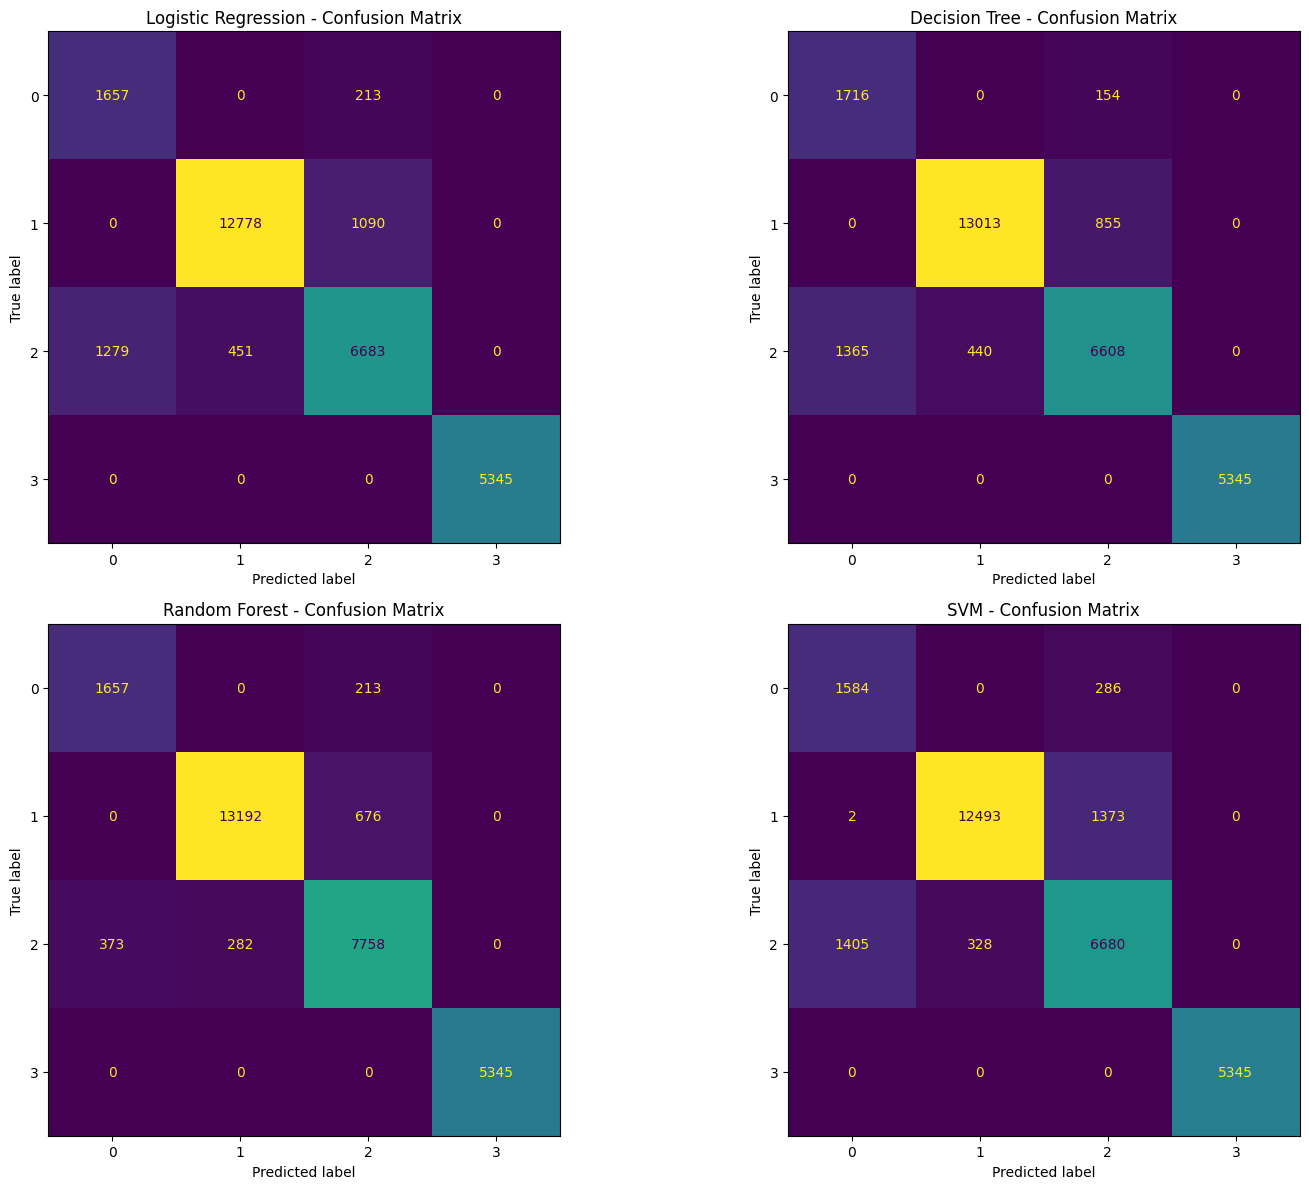

In [ ]:
# Create a 2x2 grid for confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()  # flatten to iterate easily

# Loop through each model's predictions
for ax, (name, y_pred) in zip(axes, predictions.items()):
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=sorted(pd.Series(y_test).unique()))
    
    # Display confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(pd.Series(y_test).unique())
    )
    disp.plot(ax=ax, colorbar=False)
    
    # Set title for each subplot
    ax.set_title(f"{name} - Confusion Matrix")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

## 9. Visual comparison of model metrics

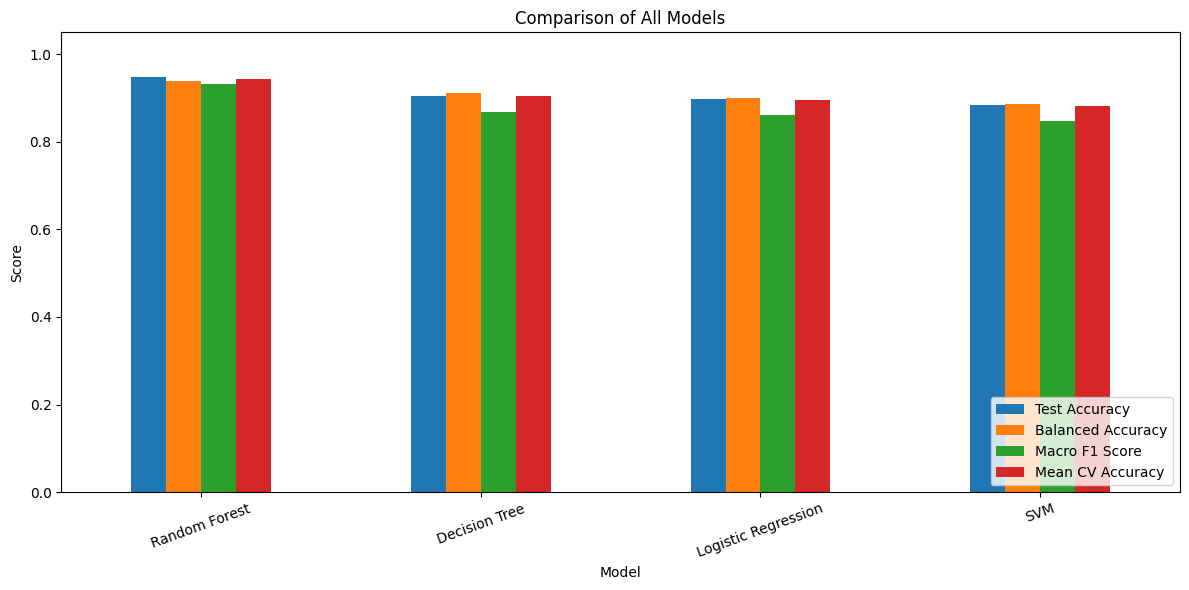

In [ ]:
# Select evaluation metrics to compare
metric_columns = ["Test Accuracy", "Balanced Accuracy", "Macro F1 Score", "Mean CV Accuracy"]

# Prepare data for plotting (set model names as index)
results_plot_df = results_df.set_index("Model")[metric_columns]

# Create bar chart for model comparison
results_plot_df.plot(kind="bar", figsize=(12, 6))

# Customize the plot
plt.title("Comparison of All Models")
plt.ylabel("Score")
plt.xticks(rotation=20)   # rotate model names
plt.ylim(0, 1.05)         # score range
plt.legend(loc="lower right")

# Adjust layout and display
plt.tight_layout()
plt.show()

## 10. Auto-select and save the best model

In [ ]:
# Select best model (top row assumed as best after sorting)
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

# Print best model details
print("Best model selected automatically:", best_model_name)
print(results_df.loc[0])

# Create folders to save outputs
models_dir = Path("../models")
reports_dir = Path("../reports")
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Define save paths
best_model_path = models_dir / "best_model.pkl"
comparison_csv_path = reports_dir / "model_comparison_results.csv"

# Save best model and comparison results
joblib.dump(best_model, best_model_path)
results_df.to_csv(comparison_csv_path, index=False)

# Confirm saving
print("\nSaved best model to:", best_model_path)
print("Saved comparison results to:", comparison_csv_path)

Best model selected automatically: Random Forest
Model                 Random Forest
Train Accuracy               0.9714
Test Accuracy                0.9477
Balanced Accuracy            0.9399
Macro F1 Score               0.9311
Weighted Precision           0.9492
Weighted Recall              0.9477
Mean CV Accuracy             0.9432
Name: 0, dtype: object

Saved best model to: ../models/best_model.pkl
Saved comparison results to: ../reports/model_comparison_results.csv


## 11. Optional: save each trained model separately

In [ ]:
# Define file names for each model
safe_names = {
    "Logistic Regression": "logistic_regression_model.pkl",
    "Decision Tree": "decision_tree_model.pkl",
    "Random Forest": "random_forest_model.pkl",
    "SVM": "svm_model.pkl",
}

# Save each trained model
for model_name, trained_model in trained_models.items():
    
    # Create file path
    save_path = Path("../models") / safe_names[model_name]
    
    # Save model as .pkl file
    joblib.dump(trained_model, save_path)
    
    # Confirm saving
    print("Saved:", save_path)

Saved: ../models/logistic_regression_model.pkl
Saved: ../models/decision_tree_model.pkl
Saved: ../models/random_forest_model.pkl
Saved: ../models/svm_model.pkl
